# Back on the pitch, back on the court

How long elite athletes are out after an ACL tear, an Achilles rupture or a meniscus tear: the five big European football leagues against the NBA, seasons 2010/11 to 2019/20.

After an ACL tear, half of the footballers are back after 212 days and half of the NBA players after 359. For an Achilles rupture the medians are 183 and 357 days. The gap shrinks but stays when the summer break is pushed to its extremes for both sports. For meniscus tears the data cannot tell the sports apart.

The two earlier projects in this series measured NBA absences from a transaction log alone. Checked against box scores, that method was wrong for most serious injuries, so the NBA side is rebuilt here first.

`get_data.py` downloads every raw table at a pinned commit and checks its SHA-256 hash.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import figures as FG
import get_data
import prepare_football as FB
import prepare_nba as NB
import survival as sv

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)

get_data.main()
RAW = Path("data/raw")
FIG, OUT = Path("figures"), Path("results")
FIG.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)
ORDER = ["ACL tear", "Achilles rupture", "Meniscus tear"]

ok        player_injuries.csv
ok        player_profiles.csv
ok        player_performances.csv
ok        nba_box_regular_1.csv


ok        nba_box_regular_2.csv
ok        nba_box_regular_3.csv
ok        nba_box_playoffs.csv
ok        nba_player_stats_1996_2023.csv


## The NBA side had to be rebuilt

`nba-return-after-injury` built absences from roster moves: the first "out" record opened an episode, the next "back" record closed it, and the diagnosis was searched across all notes of the absence. Each of its 54 Achilles, ACL and meniscus episodes is compared below with player box scores from NocturneBear/NBA-Data-2010-2024, which show the first game a player actually played.

In [2]:
events = NB.load_events("data/nba_injuries_2010-2020.csv")
box = NB.load_box([RAW / f"nba_box_regular_{i}.csv" for i in (1, 2, 3)] + [RAW / "nba_box_playoffs.csv"])
nba = NB.cohort("data/nba_injuries_2010-2020.csv",
                [RAW / f"nba_box_regular_{i}.csv" for i in (1, 2, 3)] + [RAW / "nba_box_playoffs.csv"],
                RAW / "nba_player_stats_1996_2023.csv", first_season=2010)

old = NB.legacy_cohort(events)
audit = NB.audit_legacy(old, nba, box)
audit.to_csv(OUT / "nba_old_episodes_audit.csv", index=False)

print(f"old episodes (2014/15 - 2019/20): {len(old)}")
verdicts = audit.verdict.value_counts()
print(verdicts.to_string())

old episodes (2014/15 - 2019/20): 54
verdict
correct                23
wrong return date      12
return that was not     6
wrong start             5
not a tear              4
before NBA debut        3
counted twice           1


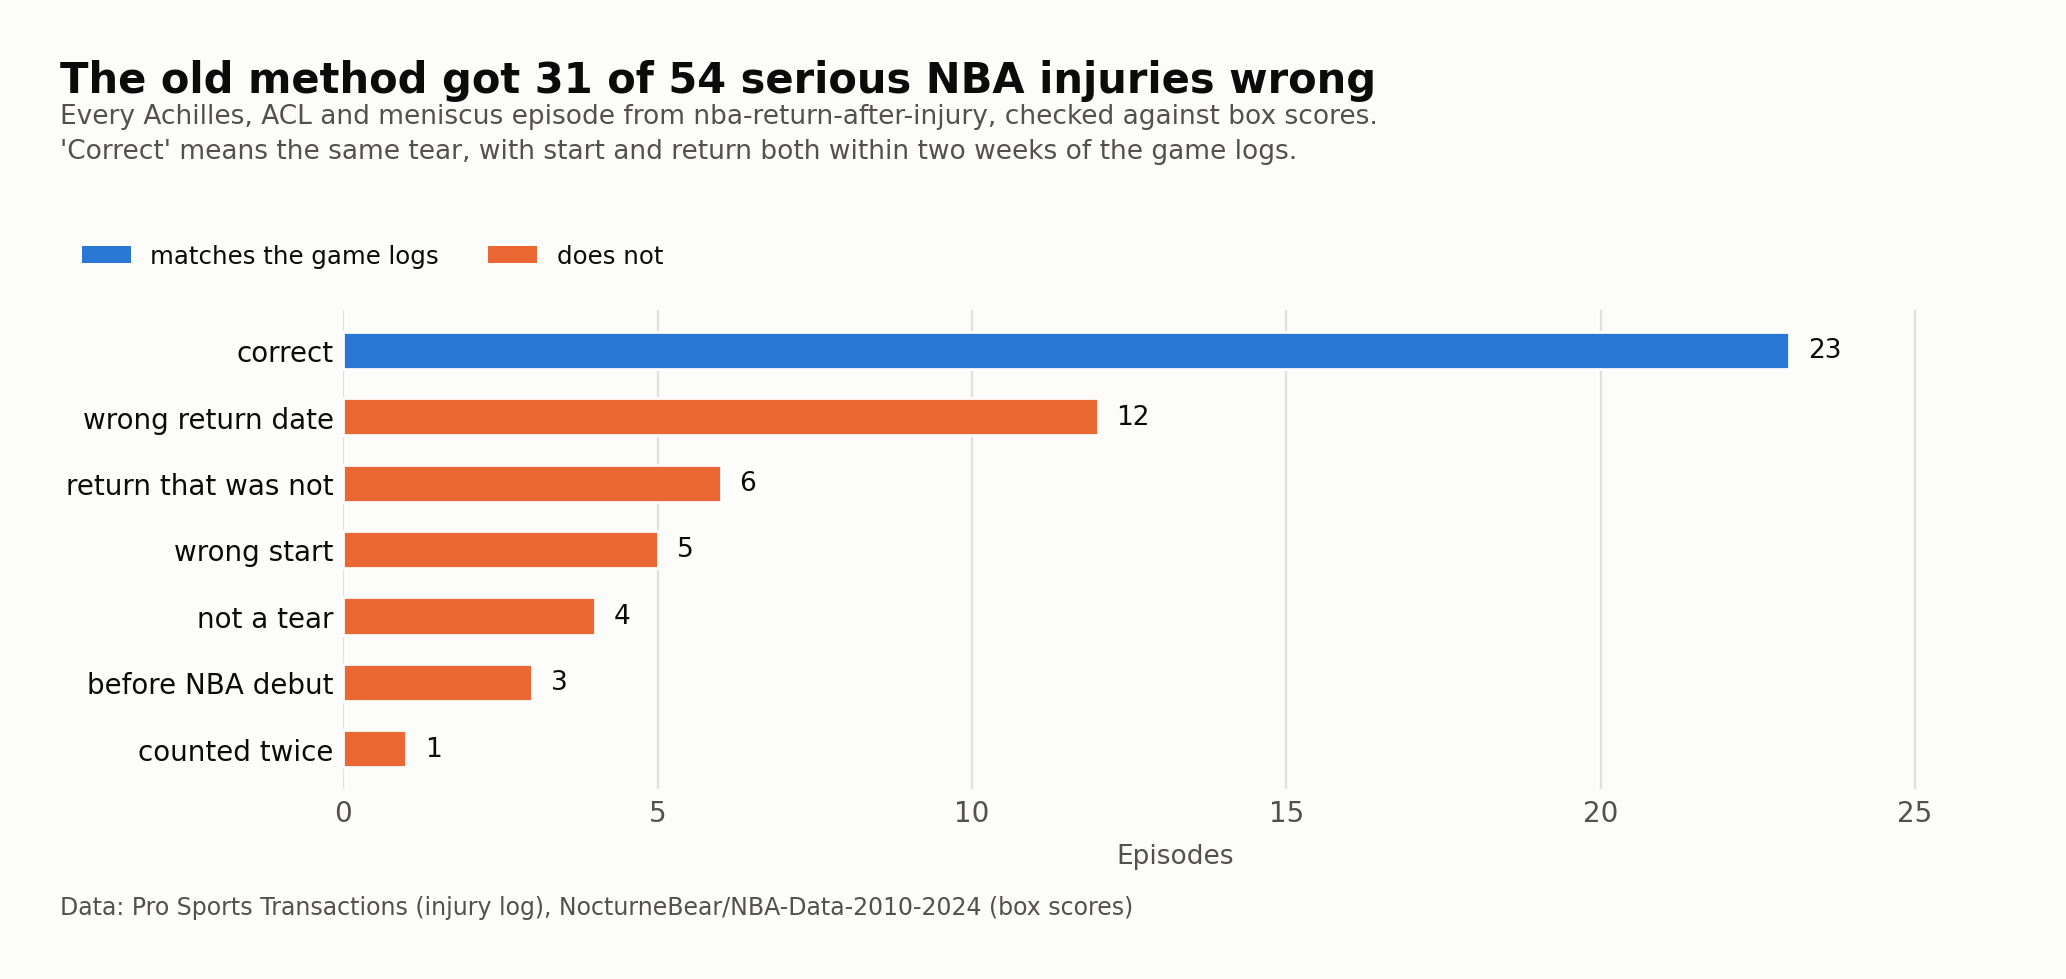

In [3]:
FG.audit_bars(
    verdicts, FIG / "04_old_method_audit.png",
    title=f"The old method got {verdicts.drop('correct').sum()} of {len(audit)} serious NBA injuries wrong",
    subtitle="Every Achilles, ACL and meniscus episode from nba-return-after-injury, checked against box scores.\n"
             "'Correct' means the same tear, with start and return both within two weeks of the game logs.",
    source="Data: Pro Sports Transactions (injury log), NocturneBear/NBA-Data-2010-2024 (box scores)")
from IPython.display import Image, display
display(Image(FIG / "04_old_method_audit.png", width=900))

Only 23 of the 54 episodes hold up. Roster moves such as waivers were logged like comebacks, missing return records glued separate absences together, and four "tears" were an ACL sprain, an adductor tear, a heel operation and an Achilles operation with no tear in the notes. The results of the previous project for these three injuries rest on this table and need a correction.

The rebuilt method takes the diagnosis from a single note that names both the body part and a tear, and takes the return from the box scores.

In [4]:
wrong_dates = audit[audit.verdict == "wrong return date"].copy()
wrong_dates["days_off"] = (pd.to_datetime(wrong_dates.old_return) - pd.to_datetime(wrong_dates.first_game_back)).dt.days
print(f"wrong return dates are off by {wrong_dates.days_off.min()} to {wrong_dates.days_off.max()} days\n")
cols = ["player", "injury", "old_start", "old_return", "verdict", "onset", "first_game_back"]
examples = pd.concat([g.head(2) for _, g in audit[audit.verdict != "correct"].groupby("verdict")])
examples[cols]

wrong return dates are off by 26 to 190 days



,player,injury,old_start,old_return,verdict,onset,first_game_back
10,O.G. Anunoby,ACL tear,2017-09-18,2018-03-15,before NBA debut,None,None
48,Davon Reed,Meniscus tear,2017-10-12,2018-01-07,before NBA debut,None,None
8,Jabari Parker,ACL tear,2017-04-10,2018-02-02,counted twice,2017-02-08,2018-02-02
12,Pau Gasol,ACL tear,2018-03-07,2018-03-10,not a tear,None,None
19,Nikola Pekovic,Achilles rupture,2015-03-13,2016-01-06,not a tear,None,None
2,Kendall Marshall,ACL tear,2015-01-17,2015-02-19,return that was not,2015-01-15,2015-12-11
5,Chris Andersen,ACL tear,2016-12-16,2017-02-13,return that was not,2016-12-14,None
3,Dante Exum,ACL tear,2015-08-06,2017-01-05,wrong return date,2015-08-06,2016-10-25
11,Kristaps Porzingis,ACL tear,2018-02-06,2020-01-21,wrong return date,2018-02-06,2019-10-23
22,C.J. Wilcox,Achilles rupture,2017-01-20,2018-10-19,wrong start,2018-09-21,None


## NBA cohort

One row per tear from 2010/11 to 2019/20. Box scores start in October 2010, which brings back the four early seasons the previous project had to drop: their problem was missing return records, and returns now come from the games.

- Onset is the game in which the player got hurt, or the date of the note if he had not played in the three days before it.
- Return is the first regular-season or playoff game he played afterwards.
- Follow-up stops on 11 March 2020, when the league suspended play. Players not back by then are censored.
- Tears before a player's first NBA game are left out. The log dates them to his first NBA listing (O.G. Anunoby's college ACL shows up in September 2017), and preseason games are not in the box scores.

In [5]:
print(f"NBA cohort, seasons 2010/11 - 2019/20: {len(nba)} tears")
summary_nba = nba.groupby("injury").agg(
    tears=("event", "size"),
    back_by_cutoff=("event", "sum"),
    back_right_after_summer=("summer_return", "sum"),
    median_age=("age", "median"),
).reindex(ORDER)
summary_nba

NBA cohort, seasons 2010/11 - 2019/20: 100 tears


,tears,back_by_cutoff,back_right_after_summer,median_age
injury,,,,
ACL tear,30,22,12,25.0
Achilles rupture,22,13,7,28.0
Meniscus tear,48,48,16,26.0


## Football cohort

Transfermarkt injury histories of players who sat in a match-day squad of the Premier League, LaLiga, Bundesliga, Serie A or Ligue 1 in the season of the injury. Back-to-back records of one player become one absence, so "Cruciate ligament tear" followed by "Fitness" ends with the second record. A label needs the body part and a tear in the same record; a broader version that also accepts "injury", "damage" and "surgery" is kept as a check. Follow-up stops on 12 March 2020, when the leagues stopped.

In [6]:
fb_all = FB.cohort(RAW / "player_injuries.csv", RAW / "player_performances.csv", RAW / "player_profiles.csv")
fb = fb_all[fb_all.injury.notna()].copy()
print(f"football cohort, seasons 2010/11 - 2019/20: {len(fb)} tears "
      f"({len(fb_all) - len(fb)} more only under the broad labels)")
summary_fb = fb.groupby("injury").agg(
    tears=("event", "size"),
    back_by_cutoff=("event", "sum"),
    rounded_end=("rounded_end", "mean"),
    median_age=("age", "median"),
).reindex(ORDER)
summary_fb["rounded_end"] = (summary_fb.rounded_end * 100).round(1)
print(summary_fb.to_string())
print("\nby league:", fb.league.value_counts().to_dict())

football cohort, seasons 2010/11 - 2019/20: 401 tears (184 more only under the broad labels)
                  tears  back_by_cutoff  rounded_end  median_age
injury                                                          
ACL tear            306             274         20.9   25.331964
Achilles rupture     45              42         20.0   28.657084
Meniscus tear        50              50         26.0   25.707050

by league: {'LaLiga': 119, 'Premier League': 76, 'Bundesliga': 73, 'Serie A': 70, 'Ligue 1': 63}


In [7]:
tm = FB.load_injuries(RAW / "player_injuries.csv")
tm = tm[tm.end.notna() & (tm.end <= FB.SNAPSHOT)]
day = tm.end.dt.strftime("%m-%d")
print(f"Transfermarkt end dates, all injuries: {len(tm)}")
for d in ("06-30", "12-31"):
    share = (day == d).mean()
    print(f"  ends on {d}: {share * 100:.1f}%  ({share * 365:.0f} times the share of an average day)")

Transfermarkt end dates, all injuries: 140675
  ends on 06-30: 2.1%  (8 times the share of an average day)
  ends on 12-31: 1.6%  (6 times the share of an average day)


A fifth of the football tears end on the first or last day of a month. Across all Transfermarkt injuries, 30 June comes up 8 times and 31 December 6 times as often as an average day. Those dates are editors' estimates, so the football results are recomputed without them further down.

## Football against the NBA

Each sport is measured in two ways.

- As recorded: the Transfermarkt end date for football, the first game played for the NBA.
- At the calendar bound. Nobody plays an NBA game in July, so a player who comes back at a season opener may have been ready months earlier. For such returns the bound moves the date back to his team's last game of the previous season, the earliest day the data allows. Football gets the opposite treatment: a player cleared in June, July or August is moved to 31 August, when all five leagues are under way.

Both bounds are extreme on purpose. They can only shrink the gap between the sports.

In [8]:
versions = [
    ("Football", "recorded", "time", "event"),
    ("Football", "bound", "time_late", "event_late"),
    ("NBA", "recorded", "time", "event"),
    ("NBA", "bound", "time_opt", "event_opt"),
]
rows = []
for inj in ORDER:
    for sport, version, t, e in versions:
        d = (fb if sport == "Football" else nba)
        d = d[d.injury == inj]
        low, high = sv.bootstrap_median(d[t], d[e], n=2000, seed=7)
        rows.append({
            "injury": inj, "sport": sport, "version": version,
            "n": len(d), "returned": int(d[e].sum()),
            "median": sv.median_time(d[t], d[e]), "low": low, "high": high,
            **{f"back_by_{x}": round(sv.returned_by(d[t], d[e], x)[0] * 100, 1) for x in (180, 270, 365)},
        })
summary = pd.DataFrame(rows)
summary.to_csv(OUT / "summary.csv", index=False)
summary

,injury,sport,version,n,returned,median,low,high,back_by_180,back_by_270,back_by_365
0,ACL tear,Football,recorded,306,274,212.0,196.0,217.0,22.2,83.3,92.6
1,ACL tear,Football,bound,306,274,219.0,212.0,228.0,18.0,77.5,92.3
2,ACL tear,NBA,recorded,30,22,359.0,324.0,446.0,0.0,7.4,53.7
3,ACL tear,NBA,bound,30,22,331.0,264.0,377.0,25.0,36.3,68.1
4,Achilles rupture,Football,recorded,45,42,183.0,158.0,205.0,46.3,84.9,97.5
5,Achilles rupture,Football,bound,45,42,190.0,174.0,220.0,41.7,82.7,97.5
6,Achilles rupture,NBA,recorded,22,13,357.0,299.0,588.0,0.0,11.1,64.3
7,Achilles rupture,NBA,bound,22,13,339.0,218.0,399.0,25.8,37.2,68.6
8,Meniscus tear,Football,recorded,50,50,71.0,56.0,99.0,86.0,98.0,98.0
9,Meniscus tear,Football,bound,50,50,83.0,56.0,107.0,84.0,98.0,98.0


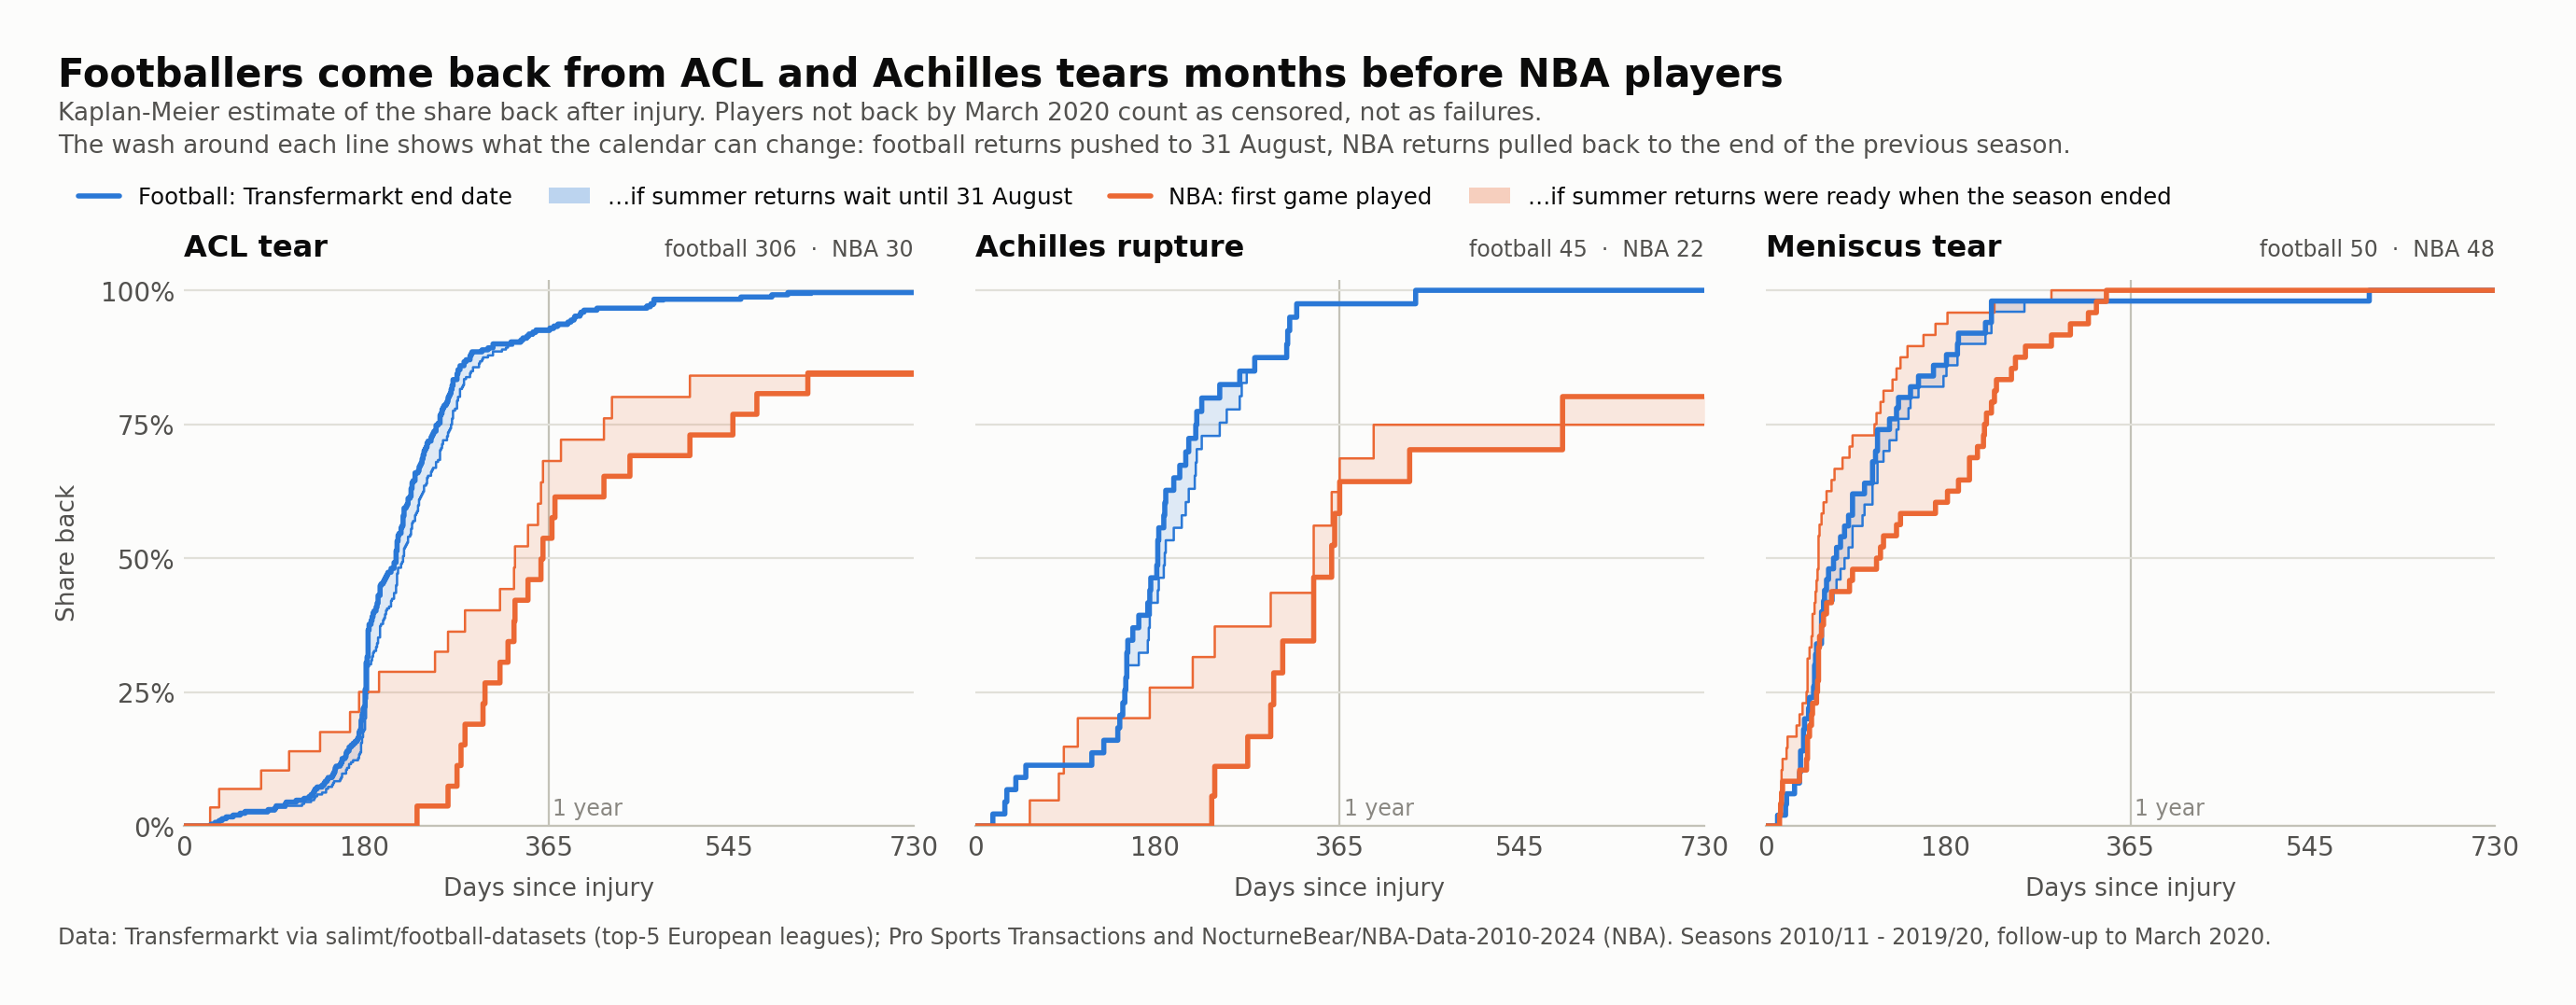

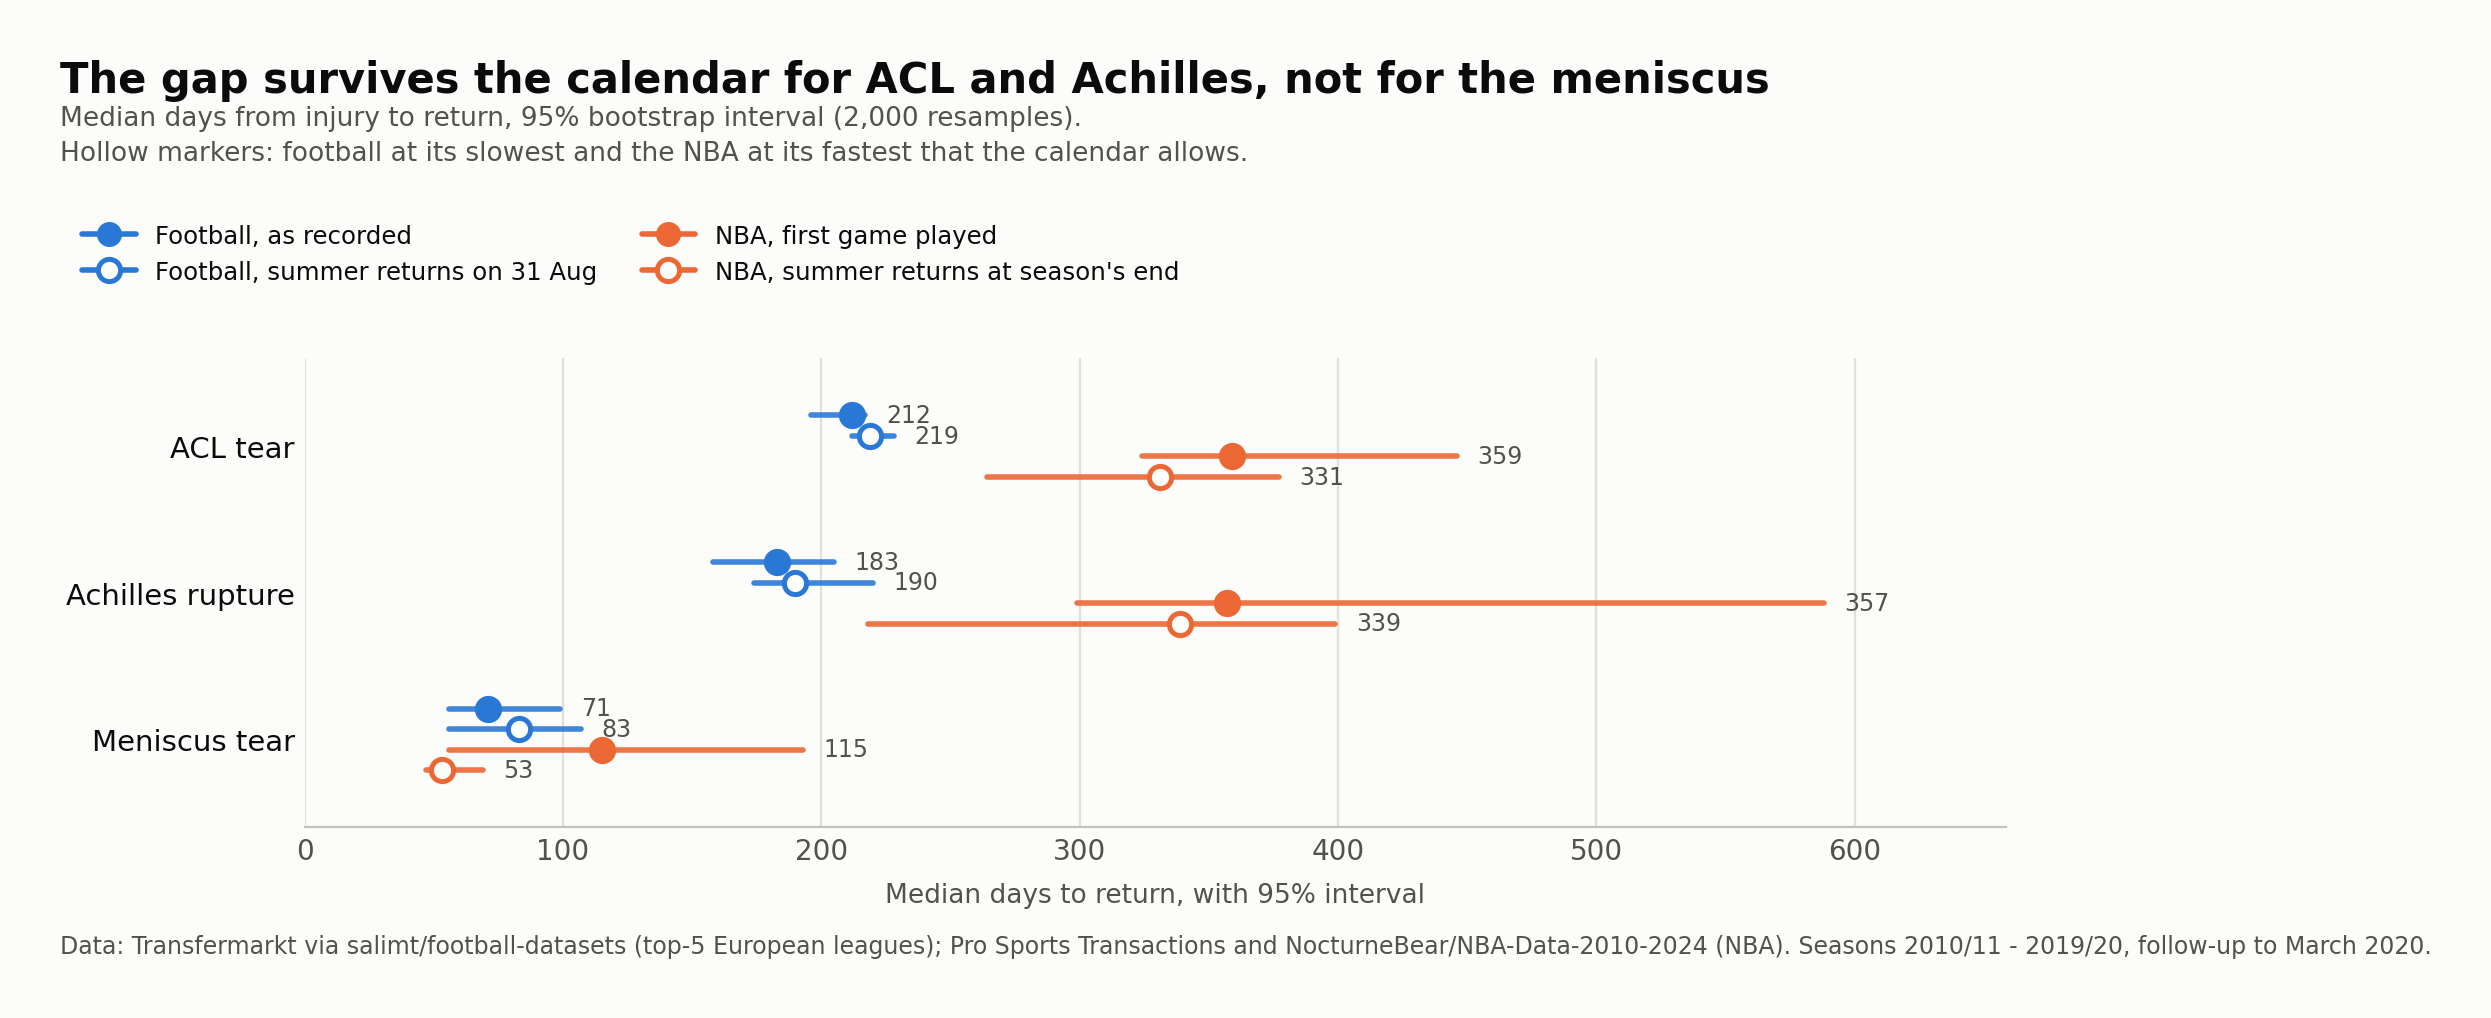

In [9]:
panels = []
for inj in ORDER:
    f, b = fb[fb.injury == inj], nba[nba.injury == inj]
    panels.append({
        "title": inj, "counts": f"football {len(f)}  ·  NBA {len(b)}",
        "football": (f.time, f.event), "football_alt": (f.time_late, f.event_late),
        "nba": (b.time, b.event), "nba_alt": (b.time_opt, b.event_opt),
    })
src = ("Data: Transfermarkt via salimt/football-datasets (top-5 European leagues); Pro Sports Transactions and "
       "NocturneBear/NBA-Data-2010-2024 (NBA). Seasons 2010/11 - 2019/20, follow-up to March 2020.")
FG.return_curves(
    panels, FIG / "01_return_curves.png",
    title="Footballers come back from ACL and Achilles tears months before NBA players",
    subtitle="Kaplan-Meier estimate of the share back after injury. Players not back by March 2020 count as censored, "
             "not as failures.\nThe wash around each line shows what the calendar can change: football returns "
             "pushed to 31 August, NBA returns pulled back to the end of the previous season.",
    source=src)
FG.medians(
    summary, FIG / "02_medians.png",
    title="The gap survives the calendar for ACL and Achilles, not for the meniscus",
    subtitle="Median days from injury to return, 95% bootstrap interval (2,000 resamples).\n"
             "Hollow markers: football at its slowest and the NBA at its fastest that the calendar allows.",
    source=src)
display(Image(FIG / "01_return_curves.png", width=980))
display(Image(FIG / "02_medians.png", width=900))

Within a year of an ACL tear, 92.6% of the footballers are back and 53.7% of the NBA players; at the bounds the NBA share rises to 68.1%. For the Achilles the one-year shares are 97.5% and 64.3%, and 68.6% at the bound. The meniscus flips: 71 against 115 days as recorded, 83 against 53 at the bounds.

## Why the calendar matters

NBA returns after ACL or Achilles tears: 35
  October to December: 28  ·  March to September: 0
football returns: 316  ·  March to September: 186 (59%)


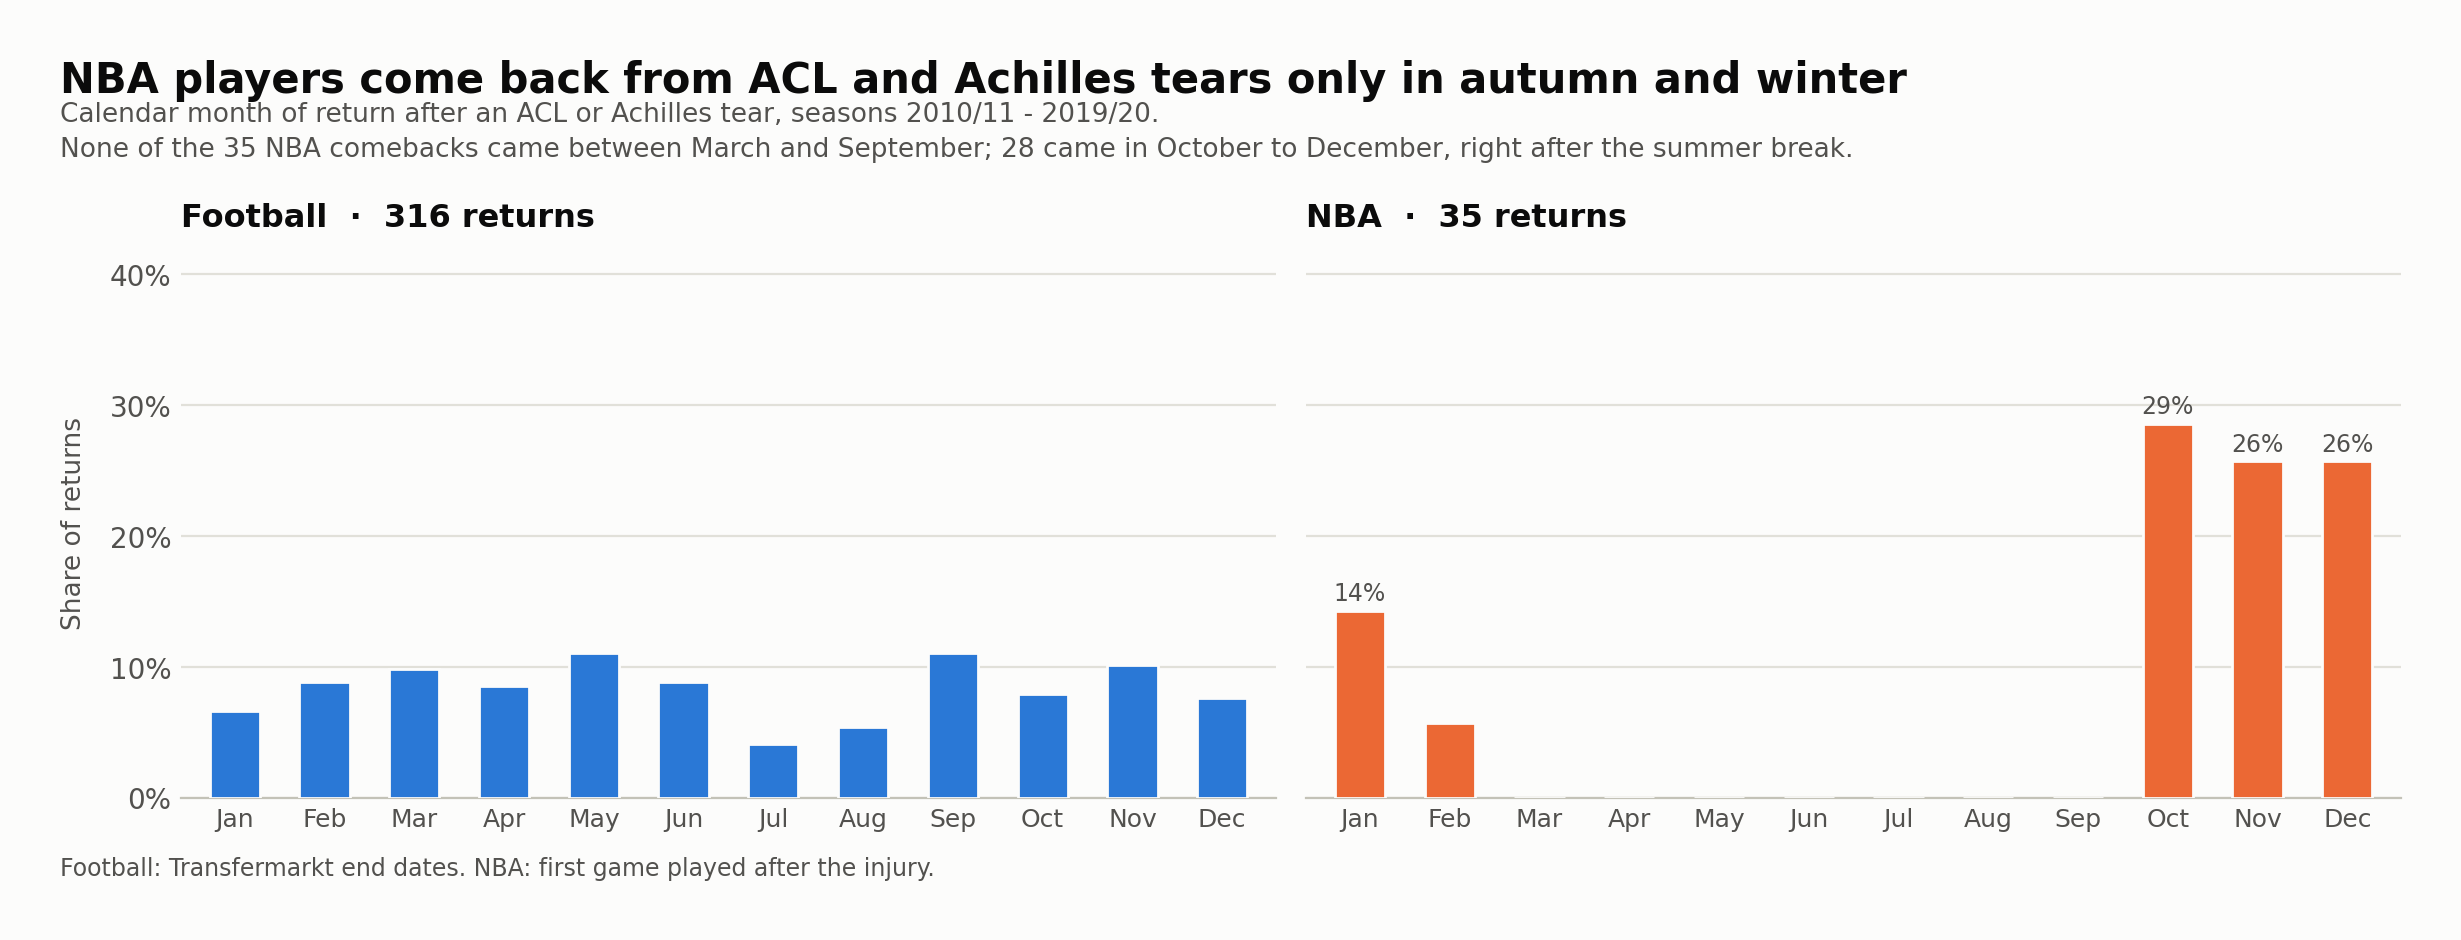

In [10]:
serious = ["ACL tear", "Achilles rupture"]
fb_back = fb[fb.injury.isin(serious) & (fb.event == 1)].end
nba_back = nba[nba.injury.isin(serious) & (nba.event == 1)].ret
nba_months = nba_back.dt.month.value_counts().reindex(range(1, 13), fill_value=0)
print(f"NBA returns after ACL or Achilles tears: {len(nba_back)}")
print(f"  October to December: {nba_months.loc[10:12].sum()}  ·  March to September: {nba_months.loc[3:9].sum()}")
fb_months = fb_back.dt.month.value_counts().reindex(range(1, 13), fill_value=0)
print(f"football returns: {len(fb_back)}  ·  March to September: {fb_months.loc[3:9].sum()} "
      f"({fb_months.loc[3:9].sum() / len(fb_back) * 100:.0f}%)")
FG.return_months(
    fb_back, nba_back, FIG / "03_return_months.png",
    title="NBA players come back from ACL and Achilles tears only in autumn and winter",
    subtitle="Calendar month of return after an ACL or Achilles tear, seasons 2010/11 - 2019/20.\n"
             f"None of the {len(nba_back)} NBA comebacks came between March and September; "
             f"{nba_months.loc[10:12].sum()} came in October to December, right after the summer break.",
    source="Football: Transfermarkt end dates. NBA: first game played after the injury.")
display(Image(FIG / "03_return_months.png", width=900))

None of the 35 NBA comebacks from an ACL or Achilles tear came between March and September; 28 came in October to December. Football returns are spread over the year, with 59% of them between March and September. That is the reason for the bounds above.

## More than noise?

Log-rank tests compare whole curves. The Cox model adds age, and the pooled model compares the sports within each injury type. A hazard ratio above 1 means footballers come back sooner.

In [11]:
def pair(inj_list, fb_cols, nba_cols):
    f = fb[fb.injury.isin(inj_list)][["injury", "age", *fb_cols]].set_axis(["injury", "age", "time", "event"], axis=1)
    b = nba[nba.injury.isin(inj_list)][["injury", "age", *nba_cols]].set_axis(["injury", "age", "time", "event"], axis=1)
    d = pd.concat([f.assign(football=1), b.assign(football=0)]).dropna(subset=["age"]).reset_index(drop=True)
    d["age_c"] = d.age - d.age.mean()
    return d

cases = {"as recorded": (["time", "event"], ["time", "event"]),
         "closest case": (["time_late", "event_late"], ["time_opt", "event_opt"])}
rows = []
for label, (fc, nc) in cases.items():
    for inj in ORDER + ["ACL + Achilles"]:
        group = serious if inj == "ACL + Achilles" else [inj]
        d = pair(group, fc, nc)
        chi, p_lr = sv.logrank(d.time, d.event, d.football) if inj != "ACL + Achilles" else (np.nan, np.nan)
        strata = "injury" if inj == "ACL + Achilles" else None
        cox = sv.cox_table(d, "time ~ football + age_c", strata=strata)
        rows.append({"version": label, "injury": inj, "n": len(d),
                     "logrank_chi2": chi, "logrank_p": p_lr,
                     "HR_football": cox.loc["football", "HR"], "HR_low": cox.loc["football", "low"],
                     "HR_high": cox.loc["football", "high"], "HR_p": cox.loc["football", "p"],
                     "HR_age": cox.loc["age_c", "HR"], "age_p": cox.loc["age_c", "p"]})
tests = pd.DataFrame(rows)
tests.to_csv(OUT / "tests.csv", index=False)
tests.round(4)

,version,injury,n,logrank_chi2,logrank_p,HR_football,HR_low,HR_high,HR_p,HR_age,age_p
0,as recorded,ACL tear,336,42.0934,0.0000,3.9768,2.5392,6.2285,0.0000,0.9984,0.9147
1,as recorded,Achilles rupture,66,27.1481,0.0000,5.7315,2.8091,11.6942,0.0000,0.9818,0.6527
2,as recorded,Meniscus tear,98,5.2295,0.0222,1.7051,1.1050,2.6310,0.0159,1.0241,0.3677
3,as recorded,ACL + Achilles,402,NaN,NaN,4.4170,3.0153,6.4703,0.0000,0.9973,0.8458
4,closest case,ACL tear,336,18.6771,0.0000,2.5413,1.6281,3.9667,0.0000,0.9892,0.4533
5,closest case,Achilles rupture,66,11.8789,0.0006,3.1117,1.5621,6.1984,0.0012,1.0074,0.8515
6,closest case,Meniscus tear,98,3.2716,0.0705,0.6889,0.4498,1.0550,0.0865,0.9975,0.9207
7,closest case,ACL + Achilles,402,NaN,NaN,2.7368,1.8806,3.9828,0.0000,0.9920,0.5539


At the bounds, footballers return sooner after an ACL tear (hazard ratio 2.54, 95% interval 1.63 to 3.97) and after an Achilles rupture (3.11, from 1.56 to 6.20); for both injuries together the ratio is 2.74 (1.88 to 3.98). Age adds nothing: per year its ratio stays between 0.98 and 1.02 with p above 0.3. For the meniscus the bound version gives 0.69 (0.45 to 1.05), which cannot separate the sports.

In [12]:
rows = []
for inj in ORDER:
    for sport, d in (("Football", fb), ("NBA", nba)):
        g = d[d.injury == inj]
        slope, se = sv.loglog_slope(g.time, g.event)
        rows.append({"injury": inj, "sport": sport, "slope": round(slope, 2), "se": round(se, 2)})
pd.DataFrame(rows).pivot(index="injury", columns="sport", values=["slope", "se"]).reindex(ORDER)

slope             se      
sport            Football   NBA Football   NBA
injury                                        
ACL tear             2.94  3.52     0.08  0.37
Achilles rupture     1.67  3.64     0.11  0.52
Meniscus tear        1.70  1.27     0.05  0.05

The proportional-hazards assumption does not hold between the sports. Slopes of log(−log S) differ, most for the Achilles (1.67 in football, 3.64 in the NBA), so the hazard ratios serve as a test of the difference and not as its size. Its size comes from the curves and the medians.

## Checks

The football medians barely move with the labels, the rounded dates or the goalkeepers: 210 to 213 days for the ACL and 180 to 184 for the Achilles. Premier League players stay out longer after an ACL tear: 243 days from 54 tears against 197 in the other four leagues, and the log-rank test below rules out chance (p = 0.00004). Whether that is medicine or the habits of the editors who keep the English pages, this data cannot say. Even the Premier League median is far below the NBA. Meniscus medians wander between 59 and 79 days.

In [13]:
def med(d, t="time", e="event"):
    return sv.median_time(d[t], d[e])

broad = fb_all[fb_all.injury_broad.notna()]
rows = []
for inj in ORDER:
    base = fb[fb.injury == inj]
    variants = {
        "main": base,
        "broad labels": broad[broad.injury_broad == inj],
        "no rounded end dates": base[~base.rounded_end],
        "no goalkeepers": base[base.main_position != "Goalkeeper"],
        "Premier League only": base[base.league == "Premier League"],
    }
    for name, d in variants.items():
        rows.append({"injury": inj, "football version": name, "n": len(d), "median": med(d)})
checks = pd.DataFrame(rows).pivot(index="football version", columns="injury", values=["n", "median"])
checks.to_csv(OUT / "football_checks.csv")

acl = fb[fb.injury == "ACL tear"]
chi, p = sv.logrank(acl.time, acl.event, acl.league == "Premier League")
print(f"ACL, Premier League against the other four leagues: log-rank chi2 = {chi:.1f}, p = {p:.2g}")
for name, d in acl.groupby(acl.league == "Premier League"):
    print(f"  {'Premier League' if name else 'other four':15s} n = {len(d):3d}  median = {med(d):.0f}")
checks

ACL, Premier League against the other four leagues: log-rank chi2 = 16.9, p = 4e-05
  other four      n = 252  median = 197
  Premier League  n =  54  median = 243


n                                  median                               
injury               ACL tear Achilles rupture Meniscus tear ACL tear Achilles rupture Meniscus tear
football version                                                                                    
Premier League only      54.0             17.0           5.0    243.0            184.0          79.0
broad labels            352.0             62.0         171.0    210.0            180.0          59.0
main                    306.0             45.0          50.0    212.0            183.0          71.0
no goalkeepers          282.0             43.0          42.0    212.0            183.0          75.0
no rounded end dates    242.0             36.0          37.0    213.0            184.0          63.0

The NBA sample is small and its medians shift when seasons are dropped. From 2014/15 on, the window of the previous project, the ACL median is 371 days and the Achilles median stays at 357. The meniscus median jumps from 115 to 204, one more reason to leave the meniscus without a verdict.

In [14]:
rows = []
for inj in ORDER:
    d = nba[nba.injury == inj]
    late = d[d.season >= 2014]
    rows.append({"injury": inj, "all seasons n": len(d), "all seasons median": med(d),
                 "2014/15+ n": len(late), "2014/15+ median": med(late)})
pd.DataFrame(rows)

,injury,all seasons n,all seasons median,2014/15+ n,2014/15+ median
0,ACL tear,30,359.0,15,371.0
1,Achilles rupture,22,357.0,16,357.0
2,Meniscus tear,48,115.0,22,204.0


Football data goes on after 2020, so its own trend can be checked. The 2020/21 season, played under pandemic rules, is left out, and recent seasons are followed until the scrape date.

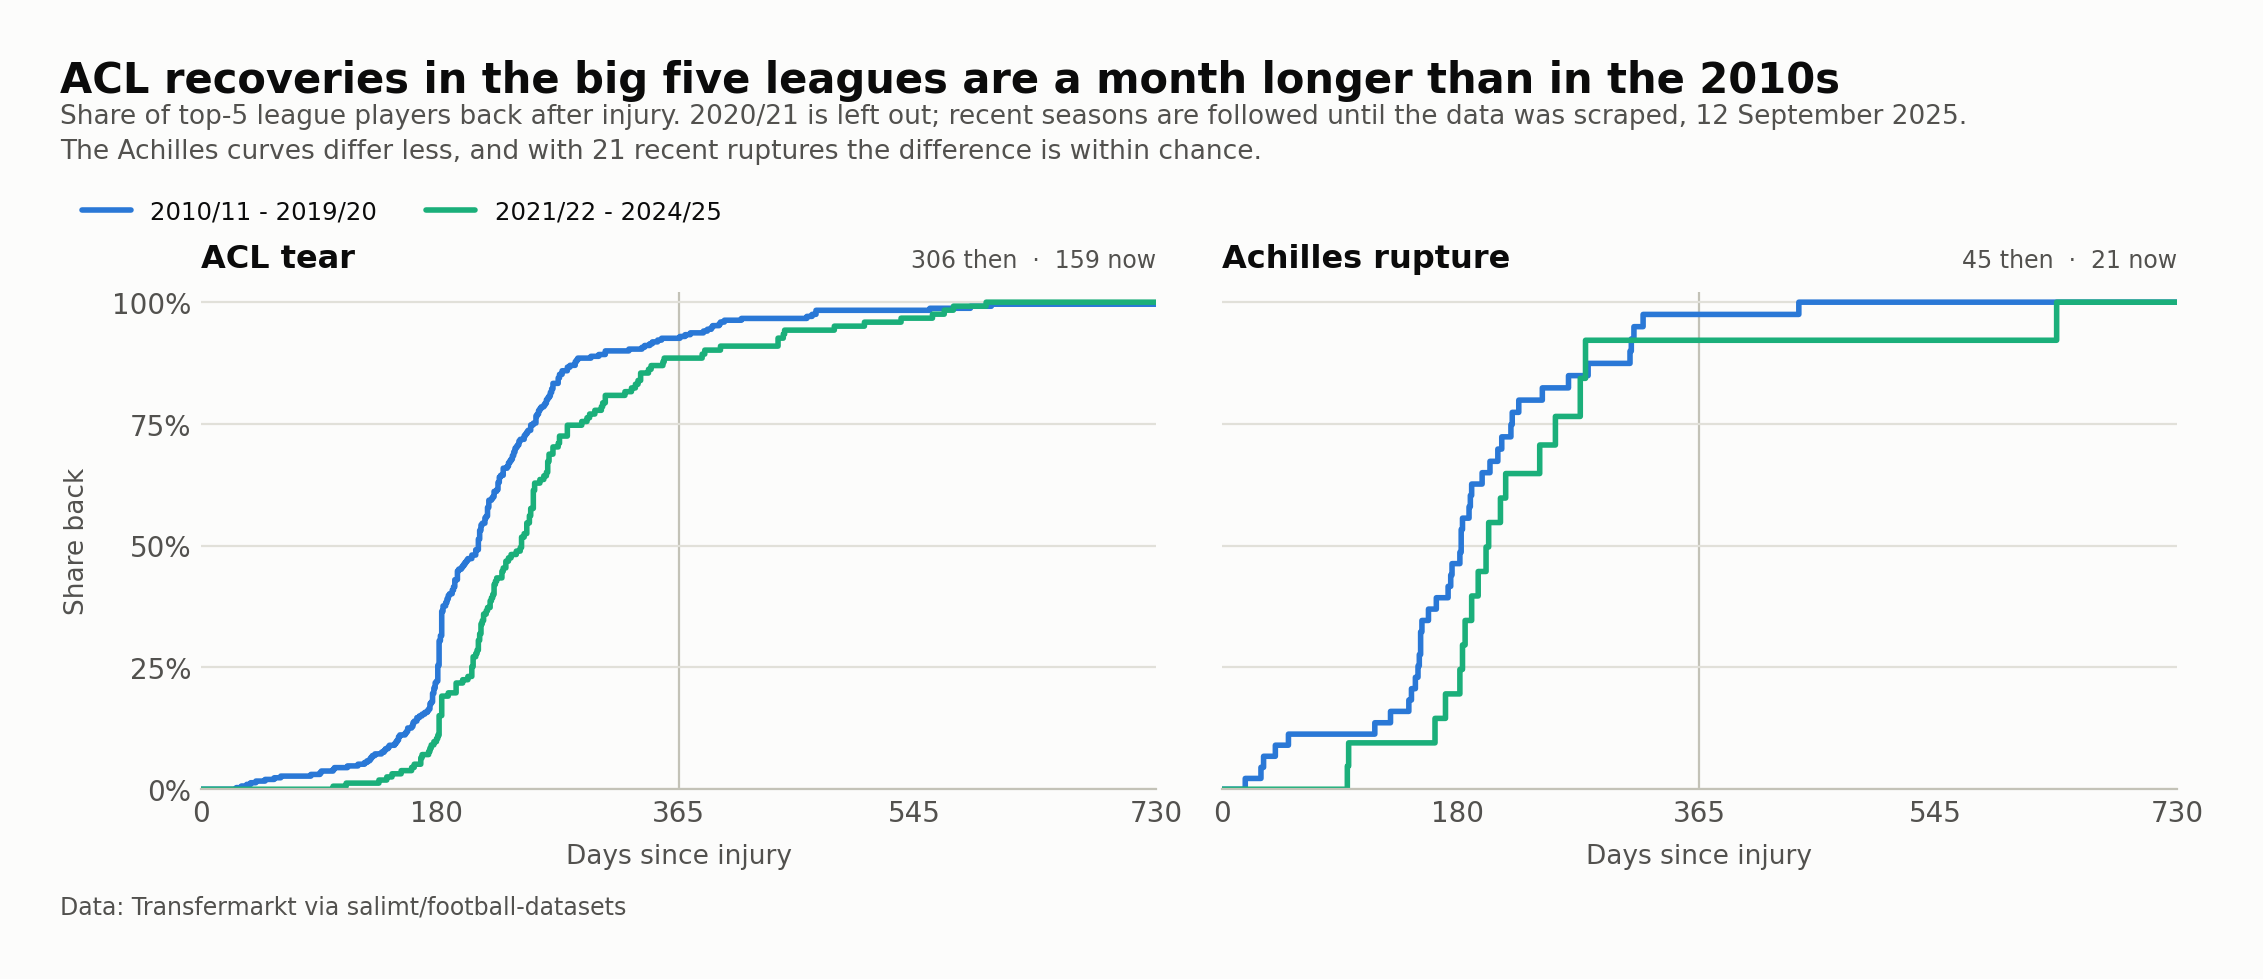

,injury,seasons,n,returned,median,low,high,back_by_365
0,ACL tear,2010/11 - 2019/20,306,274,212.0,196.0,217.0,92.6
1,ACL tear,2021/22 - 2024/25,159,140,245.0,225.0,254.0,88.5
2,Achilles rupture,2010/11 - 2019/20,45,42,183.0,158.0,205.0,97.5
3,Achilles rupture,2021/22 - 2024/25,21,18,204.0,186.0,255.0,92.2
4,Meniscus tear,2010/11 - 2019/20,50,50,71.0,56.0,99.0,98.0
5,Meniscus tear,2021/22 - 2024/25,21,20,91.0,54.0,110.0,100.0


In [15]:
recent_all = FB.cohort(RAW / "player_injuries.csv", RAW / "player_performances.csv", RAW / "player_profiles.csv",
                       first_season=2021, last_season=2024, cutoff=FB.SNAPSHOT)
recent = recent_all[recent_all.injury.notna()]
rows = []
for inj in ORDER:
    for label, d in (("2010/11 - 2019/20", fb), ("2021/22 - 2024/25", recent)):
        g = d[d.injury == inj]
        low, high = sv.bootstrap_median(g.time, g.event, n=2000, seed=7)
        rows.append({"injury": inj, "seasons": label, "n": len(g), "returned": int(g.event.sum()),
                     "median": med(g), "low": low, "high": high,
                     "back_by_365": round(sv.returned_by(g.time, g.event, 365)[0] * 100, 1)})
then_now = pd.DataFrame(rows)
then_now.to_csv(OUT / "football_then_and_now.csv", index=False)

panels = []
for inj in serious:
    a, b = fb[fb.injury == inj], recent[recent.injury == inj]
    panels.append({"title": inj, "counts": f"{len(a)} then  ·  {len(b)} now",
                   "then": (a.time, a.event), "now": (b.time, b.event)})
FG.then_and_now(
    panels, FIG / "05_football_then_and_now.png",
    title="ACL recoveries in the big five leagues are a month longer than in the 2010s",
    subtitle="Share of top-5 league players back after injury. 2020/21 is left out; recent seasons are followed "
             "until the data was scraped, 12 September 2025.\nThe Achilles curves differ less, "
             "and with 21 recent ruptures the difference is within chance.",
    source="Data: Transfermarkt via salimt/football-datasets")
display(Image(FIG / "05_football_then_and_now.png", width=900))
then_now

In [16]:
for inj in serious:
    a, b = fb[fb.injury == inj], recent[recent.injury == inj]
    chi, p = sv.logrank(np.r_[a.time, b.time], np.r_[a.event, b.event], np.r_[np.zeros(len(a)), np.ones(len(b))])
    print(f"{inj:17s} then vs now: log-rank chi2 = {chi:.1f}, p = {p:.2g}")

ACL tear          then vs now: log-rank chi2 = 14.6, p = 0.00013
Achilles rupture  then vs now: log-rank chi2 = 1.9, p = 0.17


The ACL median went from 212 to 245 days (p = 0.00013). For the Achilles it moved from 183 to 204 days with 21 recent ruptures, a difference within chance (p = 0.17). Even the longer football ACL figure stays far below the NBA.

## Against published numbers

- NBA, ACL: a 2025 meta-analysis puts mean return to play at 367 days, 95% interval 357 to 376 ([D'Ambrosi et al., Journal of ISAKOS](https://www.sciencedirect.com/science/article/pii/S2059775425006418)). The median here is 359.
- Football, ACL: the UEFA Elite Club Injury Study reports 6.6 months to team training and 7.4 months to match play ([Waldén et al., BJSM 2016](https://pubmed.ncbi.nlm.nih.gov/27034129/), summarised by [Barça Innovation Hub](https://barcainnovationhub.fcbarcelona.com/blog/recovery-time-of-the-anterior-cruciate-ligament-injury-in-elite-football/)). Transfermarkt's median of 212 days, about 7.0 months, falls between the two, and the step from training to match, under a month, is far smaller than the gap between the sports.
- Football, Achilles: UEFA players returned after a mean of 5.07 months ([Forlenza et al., OJSM 2021](https://journals.sagepub.com/doi/10.1177/23259671211024199)). The median here is 183 days, about 6.0 months.
- NBA, Achilles: players who ruptured the tendon in 2014/15 to 2024/25 played more minutes in the 10 to 15 games before the injury, in a study without a control group ([Kumar et al., OJSM 2026](https://journals.sagepub.com/doi/10.1177/23259671261463385)). It is a separate question from the one here.

## What this does not show

- Why the gap exists. Landing loads on a hard court, contract protection and league calendars are all candidates; none of them is tested here.
- The two sports use different end points. Transfermarkt records when a footballer is available again, the NBA side uses the first game played. In UEFA data that step takes under a month.
- A return is not a recovery. Nothing here measures whether a player got back to his previous level.
- The NBA sample is small: 30 ACL tears and 22 Achilles ruptures. Its direction holds under every check, its exact day counts do not.
- Transfermarkt dates are partly estimates, and the raw football data is not redistributed in this repository.
- Transfermarkt writes "cruciate ligament" without saying which one. Posterior cruciate injuries are rare in elite football (28 in 17 seasons of the UEFA study, median lay-off 31 days, [Lundblad et al., 2020](https://doaj.org/article/72b96066724a499a8e8f3049a89af6b0)), so they can only make football look slightly faster.
- NBA onsets for summer injuries come from the first log entry and can be late by weeks. Those players are few, and a late onset shortens their absence, which works against the gap.
- Follow-up in both sports stops in March 2020, before the pandemic calendar.